================================================
0. GIỚI THIỆU
================================================

Import thư viện
Cấu hình đường dẫn
Cấu hình matplotlib

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [86]:
CURRENT_DIR = Path.cwd()
BASE_DIR = CURRENT_DIR.parent

DATA_RAW = BASE_DIR / "data" / "raw" / "diabetic_data.csv"
DATA_PROCESSED = BASE_DIR / "data" / "processed" / "diabetic_cleaned_data.csv"

FIGURES_DIR = BASE_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [87]:
plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

1. DATA CLEANING

1.1 Đọc dữ liệu
1.2 Kiểm tra dữ liệu
1.3 Missing values
1.4 Duplicate
1.5 Kiểm tra patient
1.6 Loại dữ liệu không phù hợp
1.7 Xử lý missing
1.8 Outlier
1.9 Tạo target
1.10 Kiểm tra & lưu dữ liệu

In [88]:
# 1.1. Đọc dữ liệu
df = pd.read_csv(DATA_RAW)

print("Kích thước dữ liệu:", df.shape)
df.head()

Kích thước dữ liệu: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
# 1.2. Kiểm tra dữ liệu
print("Thông tin dữ liệu:")

print("Số dòng:", df.shape[0])
print("Số cột:", df.shape[1])

print("\nThông tin các cột:")
df.info()

print("\nTên các cột:")
print(df.columns.tolist())

Thông tin dữ liệu:

Số dòng: 101766
Số cột: 50

Thông tin các cột:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int6

In [ ]:
# 1.3. Missing values
df.columns = df.columns.str.strip()

df = df.replace("?", np.nan)

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Các biến có missing values:")
print(missing)

Các biến có missing values:
weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64


In [ ]:
# 1.4. Duplicate
duplicate_count = df.duplicated().sum()

print("Số dòng trùng lặp:", duplicate_count)

df = df.drop_duplicates()

print("Kích thước sau khi xóa duplicate:", df.shape)

Số dòng trùng lặp: 0
Kích thước sau khi xóa duplicate: (101766, 50)


In [92]:
# 1.5. Kiểm tra patient
print("Số bệnh nhân khác nhau:", df["patient_nbr"].nunique())
print("Số lượt khám:", df["encounter_id"].nunique())

patient_counts = df["patient_nbr"].value_counts()

print("\nSố bệnh nhân có nhiều hơn 1 lượt khám:",
      (patient_counts > 1).sum())

Số bệnh nhân khác nhau: 71518
Số lượt khám: 101766

Số bệnh nhân có nhiều hơn 1 lượt khám: 16773


In [93]:
# 1.6. Loại dữ liệu không phù hợp
expired_ids = [11, 13, 14, 19, 20, 21]

df = df[
    ~df["discharge_disposition_id"].isin(expired_ids)
].copy()

columns_to_drop = [
    "encounter_id",
    "weight",
    "payer_code",
    "medical_specialty",
    "max_glu_serum",
    "A1Cresult",
    "examide",
    "citoglipton",
    "acetohexamide",
    "troglitazone",
    "metformin-rosiglitazone",
    "metformin-pioglitazone",
    "glimepiride-pioglitazone"
]

df = df.drop(columns=columns_to_drop)

print("Kích thước sau xử lý:", df.shape)

Kích thước sau xử lý: (99343, 37)


In [94]:
# 1.7. Xử lý missing
df["gender"] = df["gender"].replace(
    "Unknown/Invalid", np.nan
)

categorical_missing = [
    "race",
    "diag_1",
    "diag_2",
    "diag_3",
    "gender"
]

for col in categorical_missing:
    df[col] = df[col].fillna("Unknown")

print("Tổng missing values:", df.isnull().sum().sum())

Tổng missing values: 0


In [95]:
# 1.8. Outlier
numeric_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

id_cols = [
    "patient_nbr",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

numeric_cols = [
    col for col in numeric_cols
    if col not in id_cols
]

outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary[col] = count

print("Số outlier theo biến:")
print(pd.Series(outlier_summary))

Số outlier theo biến:
time_in_hospital       2147
num_lab_procedures      120
num_procedures         4801
num_medications        2455
number_outpatient     16349
number_emergency      11094
number_inpatient       6814
number_diagnoses        277
dtype: int64


In [96]:
# 1.9. Tạo target
df["target_30days"] = (
    df["readmitted"] == "<30"
).astype(int)

df = df.drop(columns=["readmitted"])

print("Phân bố target:")
print(df["target_30days"].value_counts())

print("\nTỷ lệ target:")
print(
    df["target_30days"]
    .value_counts(normalize=True) * 100
)

Phân bố target:
target_30days
0    88029
1    11314
Name: count, dtype: int64

Tỷ lệ target:
target_30days
0    88.611175
1    11.388825
Name: proportion, dtype: float64


In [97]:
# 1.10. Kiểm tra và lưu dữ liệu
print("Kích thước cuối cùng:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate:", df.duplicated().sum())

print("\nCác cột cuối cùng:")
print(df.columns.tolist())

df.to_csv(
    DATA_PROCESSED,
    index=False
)

print("\nĐã lưu dữ liệu:", DATA_PROCESSED)

Kích thước cuối cùng: (99343, 37)
Missing values: 0
Duplicate: 0

Các cột cuối cùng:
['patient_nbr', 'race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'change', 'diabetesMed', 'target_30days']

Đã lưu dữ liệu: c:\Users\Hoang Viet\OneDrive\Documents\Diabetes\data\processed\diabetic_cleaned_data.csv


================================================
2. PHÂN TÍCH THỰC TRẠNG
================================================

2.1 Tổng quan target
→ Donut

2.2 Thời gian nằm viện
→ Histogram

2.3 Tái nhập viện theo tuổi
→ Lollipop

2.4 Tái nhập viện theo tiền sử nhập viện
→ Bar

2.5 Kết luận Analysis 1

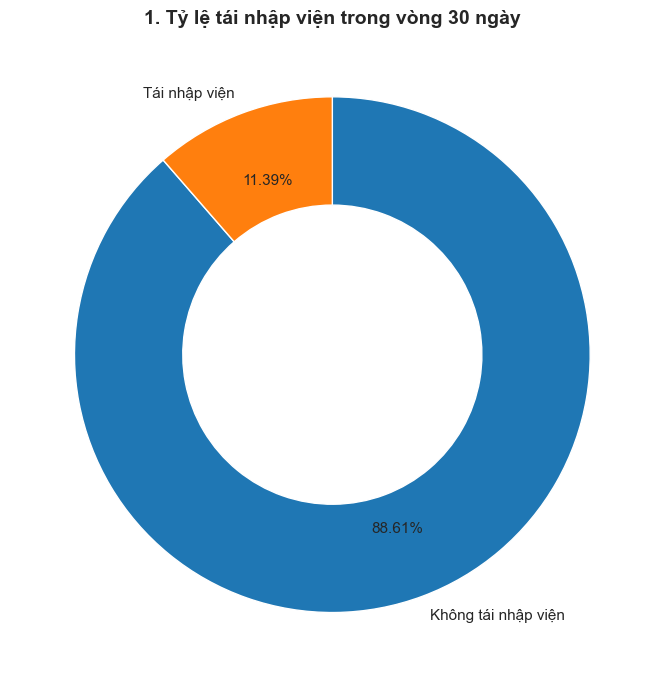

In [98]:
# 2.1. Tổng quan target -> Donut
target_counts = df["target_30days"].value_counts()

labels = ["Không tái nhập viện", "Tái nhập viện"]
values = [
    target_counts.get(0, 0),
    target_counts.get(1, 0)
]

plt.figure(figsize=(7, 7))

plt.pie(
    values,
    labels=labels,
    autopct="%1.2f%%",
    startangle=90,
    counterclock=False,
    pctdistance=0.72,       # Đưa % vào giữa vòng donut
    labeldistance=1.08,     # Đưa tên ra ngoài
    wedgeprops=dict(
        width=0.42,
        edgecolor="white"
    ),
    textprops={
        "fontsize": 11
    }
)

plt.title(
    "1. Tỷ lệ tái nhập viện trong vòng 30 ngày",
    fontweight="bold"
)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "chart1_target_donut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

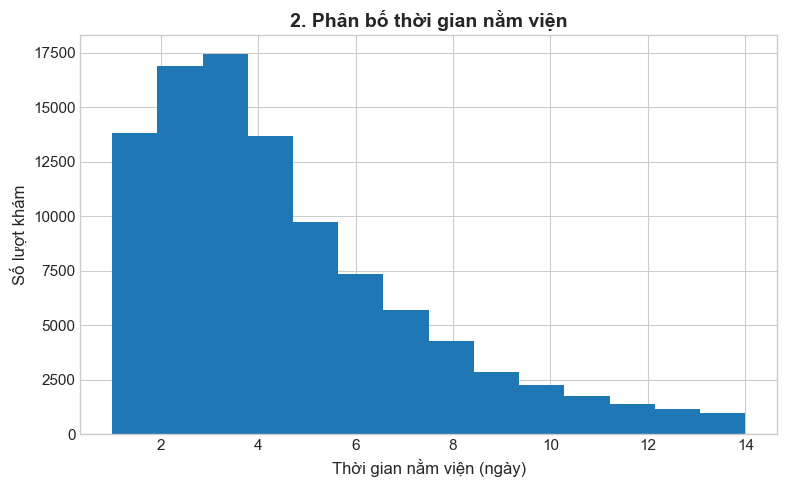

Trung bình: 4.38 ngày
Trung vị: 4 ngày
Phổ biến nhất: 3 ngày


In [99]:
# 2.2. Thời gian nằm viện -> Histogram
stay_mean = df["time_in_hospital"].mean()
stay_median = df["time_in_hospital"].median()
stay_mode = df["time_in_hospital"].mode()[0]

plt.figure(figsize=(8, 5))

plt.hist(
    df["time_in_hospital"],
    bins=14
)

plt.title(
    "2. Phân bố thời gian nằm viện",
    fontweight="bold"
)

plt.xlabel("Thời gian nằm viện (ngày)")
plt.ylabel("Số lượt khám")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "chart2_length_of_stay.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Trung bình: {stay_mean:.2f} ngày")
print(f"Trung vị: {stay_median:.0f} ngày")
print(f"Phổ biến nhất: {stay_mode} ngày")

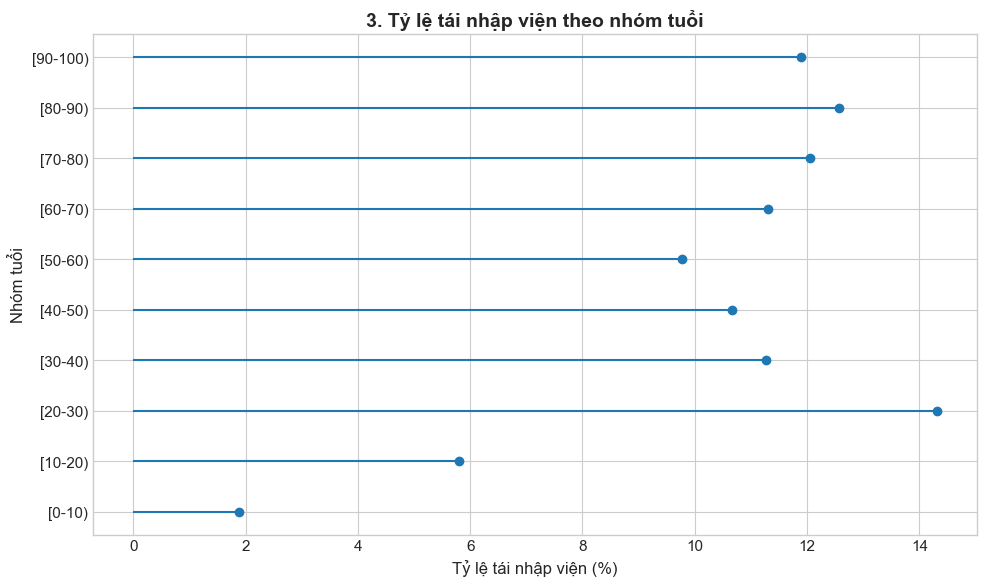

In [100]:
# 2.3. Tái nhập viện theo tuổi -> Lollipop
age_readmit = (
    df.groupby("age")["target_30days"]
    .mean() * 100
)

plt.figure(figsize=(10, 6))

plt.hlines(
    y=age_readmit.index,
    xmin=0,
    xmax=age_readmit.values
)

plt.plot(
    age_readmit.values,
    age_readmit.index,
    "o"
)

plt.title(
    "3. Tỷ lệ tái nhập viện theo nhóm tuổi",
    fontweight="bold"
)

plt.xlabel("Tỷ lệ tái nhập viện (%)")
plt.ylabel("Nhóm tuổi")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "chart3_readmission_by_age.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

highest_age_group = age_readmit.idxmax()
highest_age_rate = age_readmit.max()

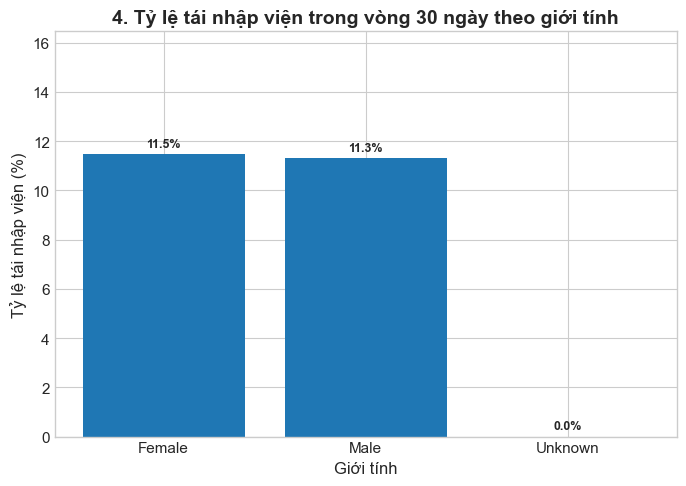

In [101]:
# 2.4. Tái nhập viện theo giới tính -> Bar
gender_readmit_rate = (
    df.groupby("gender")["target_30days"]
    .mean() * 100
)

gender_counts = df["gender"].value_counts()

largest_gender = gender_counts.idxmax()
largest_gender_pct = (
    gender_counts.max() / len(df) * 100
)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    gender_readmit_rate.index,
    gender_readmit_rate.values
)

plt.title(
    "4. Tỷ lệ tái nhập viện trong vòng 30 ngày theo giới tính",
    fontweight="bold"
)

plt.xlabel("Giới tính")
plt.ylabel("Tỷ lệ tái nhập viện (%)")

for bar, rate in zip(
    bars,
    gender_readmit_rate.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        rate + 0.3,
        f"{rate:.1f}%",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.ylim(
    0,
    gender_readmit_rate.max() + 5
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "chart4_readmission_by_gender.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [102]:
# 2.5. Kết luận Analysis 1
pct_readmit = df["target_30days"].mean() * 100

print("\nTỔNG KẾT PHÂN TÍCH THỰC TRẠNG - TV2")

print(
    f"- Tỷ lệ tái nhập viện chung (< 30 ngày): "
    f"{pct_readmit:.2f}%."
)

print(
    f"- Thời gian nằm viện: Trung bình "
    f"{stay_mean:.2f} ngày; Phổ biến nhất "
    f"là {stay_mode} ngày."
)

print(
    f"- Giới tính chiếm đa số: "
    f"{largest_gender} ({largest_gender_pct:.2f}%)."
)

print(
    f"- Nhóm tuổi có tỷ lệ tái nhập viện cao nhất: "
    f"{highest_age_group} ({highest_age_rate:.1f}%)."
)


TỔNG KẾT PHÂN TÍCH THỰC TRẠNG - TV2
- Tỷ lệ tái nhập viện chung (< 30 ngày): 11.39%.
- Thời gian nằm viện: Trung bình 4.38 ngày; Phổ biến nhất là 3 ngày.
- Giới tính chiếm đa số: Female (53.81%).
- Nhóm tuổi có tỷ lệ tái nhập viện cao nhất: [20-30) (14.3%).


================================================
3. PHÂN TÍCH MỐI QUAN HỆ
================================================

3.1 time_in_hospital ↔ num_medications
→ Scatter

3.2 target ↔ number_inpatient
→ Bar

3.3 target ↔ number_emergency
→ Bar

3.4 target ↔ number_outpatient
→ Bar

3.5 age ↔ time_in_hospital
→ Boxplot

3.6 Kết luận Analysis 2

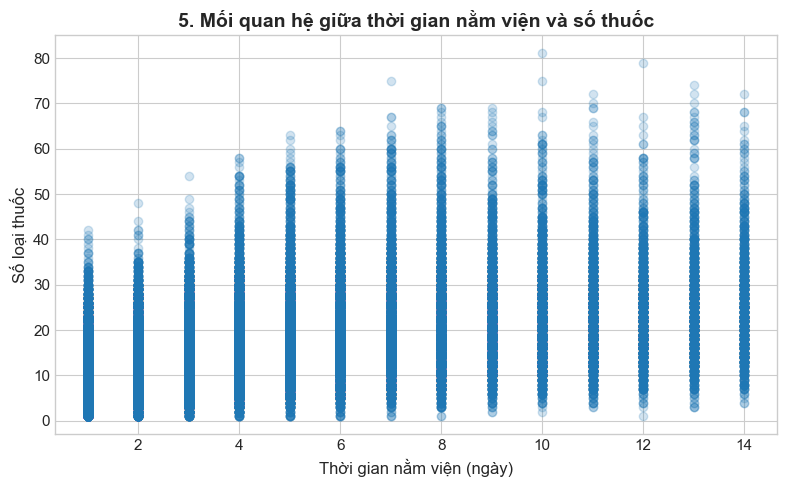

Pearson correlation: r = 0.464


In [103]:
# 3.1 time_in_hospital ↔ num_medications → Scatter
correlation = df[
    ["time_in_hospital", "num_medications"]
].corr().iloc[0, 1]

plt.figure(figsize=(8, 5))

plt.scatter(
    df["time_in_hospital"],
    df["num_medications"],
    alpha=0.2
)

plt.title(
    "5. Mối quan hệ giữa thời gian nằm viện và số thuốc",
    fontweight="bold"
)

plt.xlabel("Thời gian nằm viện (ngày)")
plt.ylabel("Số loại thuốc")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "chart5_stay_medications.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Pearson correlation: r = {correlation:.3f}")

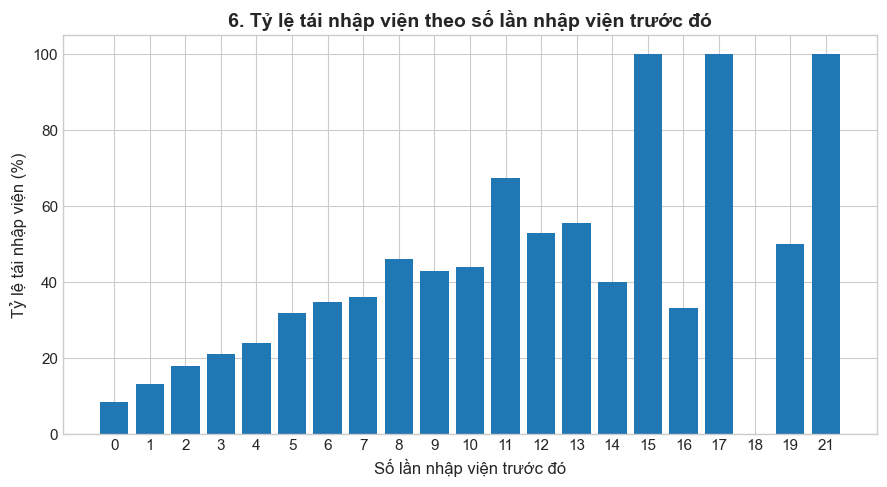

In [104]:
# 3.2 target ↔ number_inpatient → Bar
inpatient_rate = (
    df.groupby("number_inpatient")["target_30days"]
    .mean() * 100
)

plt.figure(figsize=(9, 5))

plt.bar(
    inpatient_rate.index.astype(str),
    inpatient_rate.values
)

plt.title(
    "6. Tỷ lệ tái nhập viện theo số lần nhập viện trước đó",
    fontweight="bold"
)

plt.xlabel("Số lần nhập viện trước đó")
plt.ylabel("Tỷ lệ tái nhập viện (%)")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "chart6_inpatient.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

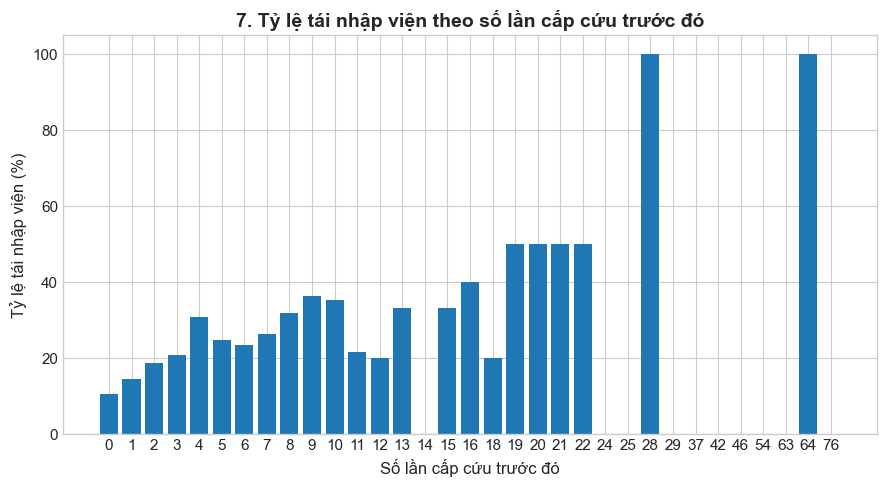

In [105]:
# 3.3 target ↔ number_emergency → Bar
emergency_rate = (
    df.groupby("number_emergency")["target_30days"]
    .mean() * 100
)

plt.figure(figsize=(9, 5))

plt.bar(
    emergency_rate.index.astype(str),
    emergency_rate.values
)

plt.title(
    "7. Tỷ lệ tái nhập viện theo số lần cấp cứu trước đó",
    fontweight="bold"
)

plt.xlabel("Số lần cấp cứu trước đó")
plt.ylabel("Tỷ lệ tái nhập viện (%)")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "chart7_emergency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

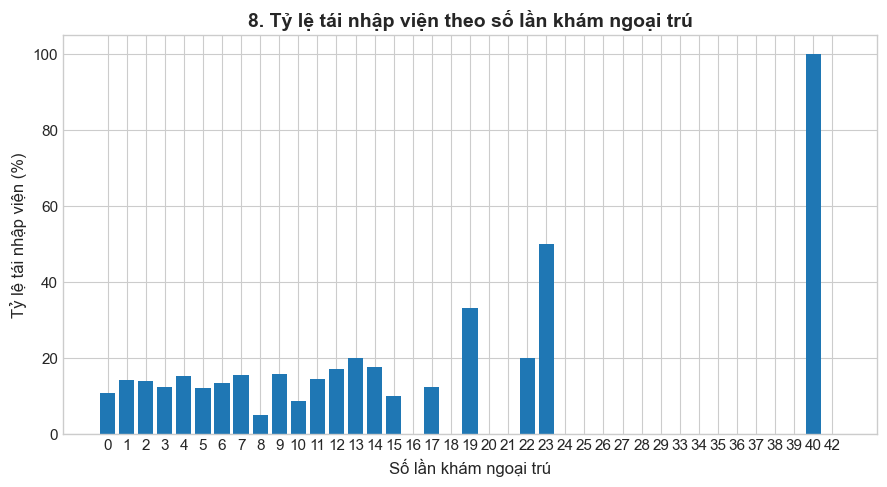

In [106]:
# 3.4 target ↔ number_outpatient → Bar
outpatient_rate = (
    df.groupby("number_outpatient")["target_30days"]
    .mean() * 100
)

plt.figure(figsize=(9, 5))

plt.bar(
    outpatient_rate.index.astype(str),
    outpatient_rate.values
)

plt.title(
    "8. Tỷ lệ tái nhập viện theo số lần khám ngoại trú",
    fontweight="bold"
)

plt.xlabel("Số lần khám ngoại trú")
plt.ylabel("Tỷ lệ tái nhập viện (%)")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "chart8_outpatient.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

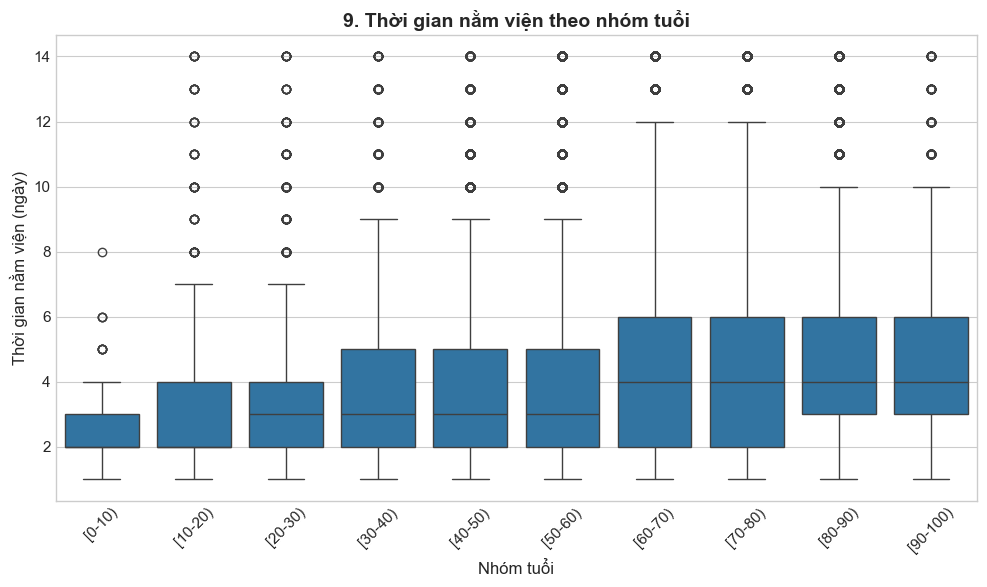

In [107]:
# 3.5 age ↔ time_in_hospital → Boxplot
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="age",
    y="time_in_hospital"
)

plt.title(
    "9. Thời gian nằm viện theo nhóm tuổi",
    fontweight="bold"
)

plt.xlabel("Nhóm tuổi")
plt.ylabel("Thời gian nằm viện (ngày)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "chart9_age_stay_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [108]:
# 3.6 Kết luận Analysis 2
target_corr = (
    df.corr(numeric_only=True)["target_30days"]
    .drop("target_30days")
    .sort_values(
        key=abs,
        ascending=False
    )
)

print("\nTỔNG KẾT PHÂN TÍCH MỐI QUAN HỆ - TV3")

print(
    f"- Biến có tương quan lớn nhất với target: "
    f"{target_corr.index[0]} "
    f"(r = {target_corr.iloc[0]:.3f})."
)

print(
    f"- time_in_hospital và num_medications: "
    f"r = {correlation:.3f}."
)

print(
    "- Các nhóm có tiền sử nhập viện/cấp cứu "
    "khác nhau có tỷ lệ tái nhập viện khác nhau."
)

print(
    "- Các kết quả thể hiện mối liên hệ, "
    "không khẳng định quan hệ nhân quả."
)


TỔNG KẾT PHÂN TÍCH MỐI QUAN HỆ - TV3
- Biến có tương quan lớn nhất với target: number_inpatient (r = 0.168).
- time_in_hospital và num_medications: r = 0.464.
- Các nhóm có tiền sử nhập viện/cấp cứu khác nhau có tỷ lệ tái nhập viện khác nhau.
- Các kết quả thể hiện mối liên hệ, không khẳng định quan hệ nhân quả.


================================================
4. PREDICTION / MACHINE LEARNING
================================================

4.1 X / y
4.2 Train/Test
4.3 Patient leakage
4.4 Class imbalance
4.5 Preprocessing
4.6 Logistic Regression
4.7 Random Forest
4.8 Evaluation
4.9 Model comparison
4.10 Confusion Matrix
4.11 ROC Curve
4.12 Feature Importance
4.13 Kết luận

In [109]:
# 4.1 X / y
X = df.drop(columns=["target_30days"])
y = df["target_30days"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (99343, 36)
y shape: (99343,)


In [110]:
# 4.2 Train/Test
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        X,
        y,
        groups=df["patient_nbr"]
    )
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (79541, 36)
Test: (19802, 36)


In [111]:
# 4.3 Patient leakage
train_patients = set(
    X_train["patient_nbr"]
)

test_patients = set(
    X_test["patient_nbr"]
)

overlap = train_patients.intersection(
    test_patients
)

print("Số patient trùng giữa Train/Test:", len(overlap))

Số patient trùng giữa Train/Test: 0


In [112]:
# 4.4 Class imbalance
print("Train target distribution:")
print(y_train.value_counts())

print("\nTrain target percentage:")
print(
    y_train.value_counts(normalize=True) * 100
)

Train target distribution:
target_30days
0    70443
1     9098
Name: count, dtype: int64

Train target percentage:
target_30days
0    88.561874
1    11.438126
Name: proportion, dtype: float64


In [113]:
# 4.5 Preprocessing
categorical_cols = [
    col for col in X_train.columns
    if X_train[col].dtype == "object"
]

numerical_cols = [
    col for col in X_train.columns
    if col not in categorical_cols
]

print("Categorical:", len(categorical_cols))
print("Numerical:", len(numerical_cols))

Categorical: 24
Numerical: 12


In [114]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(
        strategy="most_frequent"
    )),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(
        strategy="median"
    )),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    (
        "cat",
        categorical_pipeline,
        categorical_cols
    ),
    (
        "num",
        numerical_pipeline,
        numerical_cols
    )
])

In [115]:
# 4.6 Logistic Regression
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        C=0.01,
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](36,)","['patient_nbr','race','gender',...,'glipizide-metformin','change', 'diabetesMed']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,36
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthroug

In [116]:
# 4.7 Random Forest
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_split=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](36,)","['patient_nbr','race','gender',...,'glipizide-metformin','change', 'diabetesMed']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,36
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthroug

In [117]:
# 4.8 Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

lr_pred = logistic_model.predict(X_test)
lr_prob = logistic_model.predict_proba(X_test)[:, 1]

rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

In [118]:
print("LOGISTIC REGRESSION")

print(
    "Accuracy:",
    accuracy_score(y_test, lr_pred)
)

print(
    "Precision:",
    precision_score(y_test, lr_pred)
)

print(
    "Recall:",
    recall_score(y_test, lr_pred)
)

print(
    "F1:",
    f1_score(y_test, lr_pred)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, lr_prob)
)


print("\nRANDOM FOREST")

print(
    "Accuracy:",
    accuracy_score(y_test, rf_pred)
)

print(
    "Precision:",
    precision_score(y_test, rf_pred)
)

print(
    "Recall:",
    recall_score(y_test, rf_pred)
)

print(
    "F1:",
    f1_score(y_test, rf_pred)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, rf_prob)
)

LOGISTIC REGRESSION
Accuracy: 0.663922836077164
Precision: 0.17470320973178954
Recall: 0.5379061371841155
F1: 0.2637459896006195
ROC-AUC: 0.6566250906838021

RANDOM FOREST
Accuracy: 0.668013331986668
Precision: 0.1737047020065888
Recall: 0.5234657039711191
F1: 0.26085001124353496
ROC-AUC: 0.6539937977822038


In [119]:
# 4.9 Model comparison
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.663923,0.174703,0.537906,0.263746,0.656625
1,Random Forest,0.668013,0.173705,0.523466,0.260850,0.653994


In [120]:
# 4.10 Confusion Matrix
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(
    y_test,
    lr_pred
)

cm_rf = confusion_matrix(
    y_test,
    rf_pred
)

print("Logistic Regression:")
print(cm_lr)

print("\nRandom Forest:")
print(cm_rf)

Logistic Regression:
[[11955  5631]
 [ 1024  1192]]

Random Forest:
[[12068  5518]
 [ 1056  1160]]


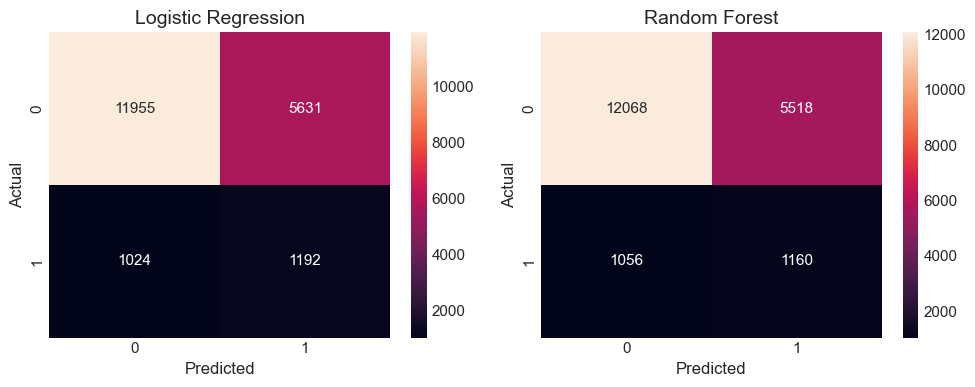

In [121]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 4)
)

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    ax=axes[0]
)

axes[0].set_title(
    "Logistic Regression"
)

axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")


sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    ax=axes[1]
)

axes[1].set_title(
    "Random Forest"
)

axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "confusion_matrix_models.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

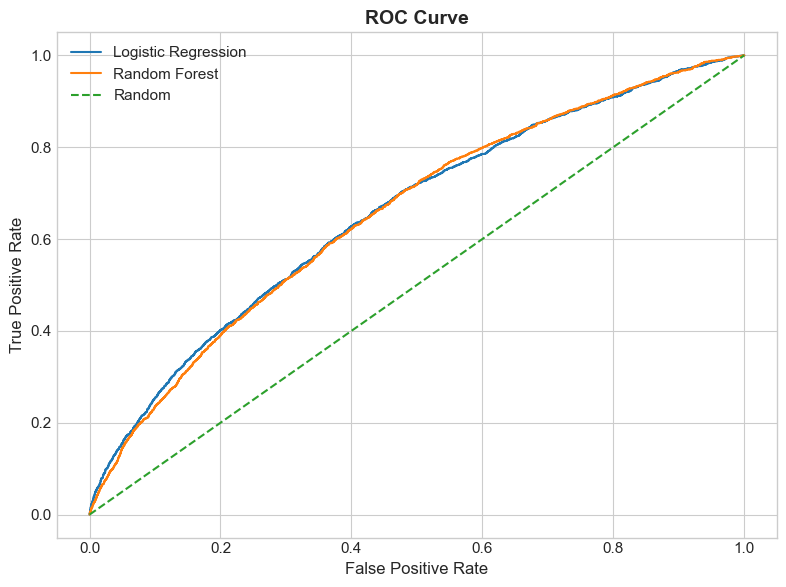

In [122]:
# 4.11 ROC Curve
from sklearn.metrics import roc_curve

lr_fpr, lr_tpr, _ = roc_curve(
    y_test,
    lr_prob
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label="Logistic Regression"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label="Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve",
    fontweight="bold"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

num__number_inpatient            0.131058
num__discharge_disposition_id    0.055548
num__num_medications             0.036717
num__time_in_hospital            0.035402
num__patient_nbr                 0.034734
num__number_emergency            0.030171
num__num_lab_procedures          0.029060
num__number_diagnoses            0.028809
num__num_procedures              0.015755
num__number_outpatient           0.015354
num__admission_type_id           0.013079
num__admission_source_id         0.012405
cat__age_[50-60)                 0.008385
cat__insulin_Down                0.008367
cat__diag_3_250                  0.007953
cat__insulin_No                  0.007880
cat__metformin_No                0.007102
cat__diag_1_V58                  0.006850
cat__diag_1_786                  0.006615
cat__metformin_Steady            0.006608
dtype: float64


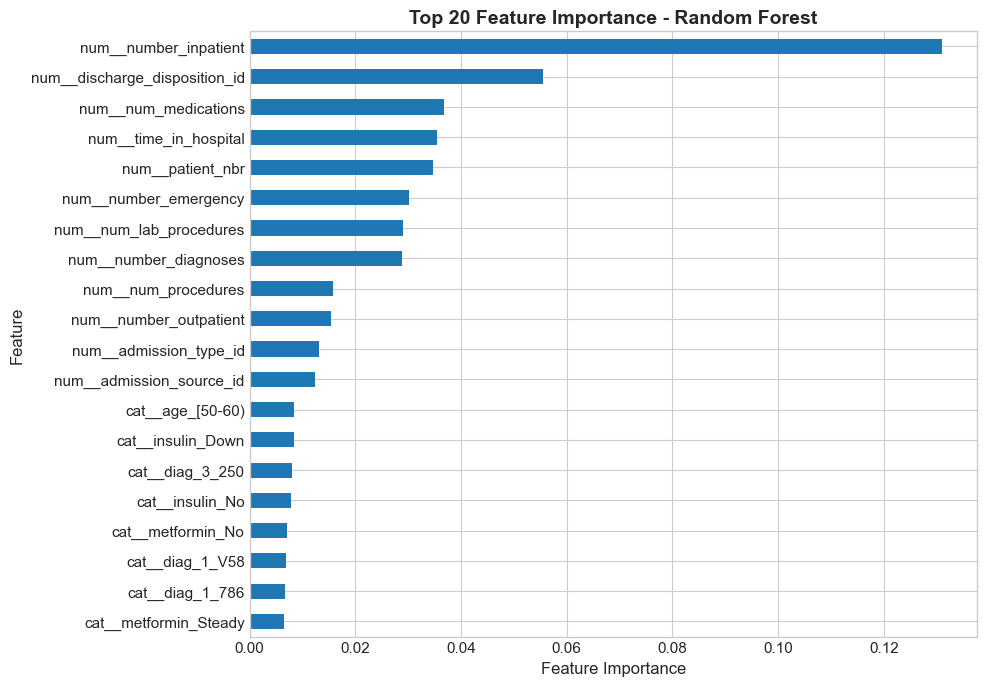

In [123]:
# 4.12 Feature Importance
rf_preprocessor = (
    random_forest_model
    .named_steps["preprocessor"]
)

rf_model = (
    random_forest_model
    .named_steps["model"]
)

feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)

importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(
    ascending=False
)

top20 = importance.head(20)

print(top20)
plt.figure(figsize=(10, 7))

top20.sort_values().plot(
    kind="barh"
)

plt.title(
    "Top 20 Feature Importance - Random Forest",
    fontweight="bold"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [124]:
# 4.13 Kết luận
print("\nTỔNG KẾT PREDICTION / MACHINE LEARNING")

print(
    f"- Logistic Regression: "
    f"F1 = {f1_score(y_test, lr_pred):.4f}, "
    f"ROC-AUC = {roc_auc_score(y_test, lr_prob):.4f}."
)

print(
    f"- Random Forest: "
    f"F1 = {f1_score(y_test, rf_pred):.4f}, "
    f"ROC-AUC = {roc_auc_score(y_test, rf_prob):.4f}."
)

print(
    f"- Biến có Feature Importance cao nhất: "
    f"{importance.index[0]} "
    f"({importance.iloc[0]:.4f})."
)

print(
    "- Feature Importance thể hiện mức độ đóng góp "
    "của biến vào mô hình, không khẳng định quan hệ nhân quả."
)


TỔNG KẾT PREDICTION / MACHINE LEARNING
- Logistic Regression: F1 = 0.2637, ROC-AUC = 0.6566.
- Random Forest: F1 = 0.2609, ROC-AUC = 0.6540.
- Biến có Feature Importance cao nhất: num__number_inpatient (0.1311).
- Feature Importance thể hiện mức độ đóng góp của biến vào mô hình, không khẳng định quan hệ nhân quả.
